## Exploratory Analysis of Data
Dataset: BCI Competition 2008 – Graz data set A

https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_001.html

In [1]:
from moabb.datasets import BNCI2014_001
dataset = BNCI2014_001()


c:\Users\Hzaab\Desktop\intern\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#example to display data from subject 1
sessions = dataset.get_data(subjects=[1])

print(sessions)
print("first session: \n")
print(sessions[1])

{1: {'0train': {'0': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '1': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '2': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '3': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '4': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '5': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>}, '1test': {'0': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '1': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '2': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '3': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '4': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '5': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>}}}
first session: 

{'0train': {'0': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '1': <RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>, '2': <RawArray | 26 x 96735 (386.9 s), ~19.2 M

In [3]:
subject = 1
session_name = "0train"
run_name = "0"

sessions = dataset.get_data(subjects=[1])
raw = sessions[subject][session_name][run_name]
#one run in a session
raw

<RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>

In [4]:
import moabb.paradigms as mp
paradigm=mp.MotorImagery(scorer=["accuracy", "balanced_accuracy", "f1_macro"])

Choosing from all possible events


In [5]:
X, labels, meta = paradigm.get_data(dataset=dataset, subjects=[1])
#X: EEG trials
#labels: the classification label corresponding to X
#meta: the metadata for the trial

In [7]:
X.shape
#576 trials: 6 runs, 48 trials per run (12 for each of the 4 classes), 2 sessions, 6 x 48 x 2 = 576
#22 channels
#10001 samples: 250 Hz used, so 10001/250= 4 seconds of data, matches diagram

(576, 22, 1001)

In [8]:
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

pipeline = make_pipeline( #common spatial patterns to enhance differences, followed by Linear discriminative analysis for classification
    CSP(n_components=8),
    LDA()
)

In [9]:
from moabb.evaluations import WithinSessionEvaluation
evaluation = WithinSessionEvaluation( #k fold cross validation
    paradigm=paradigm, datasets=[dataset], overwrite=True, hdf5_path=None, 
)

In [10]:
results = evaluation.process({"csp+lda": pipeline})

Computing rank from data with rank=None
    Using tolerance 44 (2.2e-16 eps * 22 dim * 9.1e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 44 (2.2e-16 eps * 22 dim * 9.1e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 44 (2.2e-16 eps * 22 dim * 9e+15

In [11]:
results

,score,time,samples,samples_test,n_classes,score_accuracy,score_balanced_accuracy,score_f1_macro,subject,session,channels,n_sessions,dataset,pipeline
0,0.548578,0.622382,288.0,57.0,4.0,0.548578,0.549286,0.539999,4,0train,22,2,BNCI2014-001,csp+lda
1,0.663097,0.548014,288.0,57.0,4.0,0.663097,0.661667,0.658255,4,1test,22,2,BNCI2014-001,csp+lda
2,0.673140,0.567100,288.0,57.0,4.0,0.673140,0.671667,0.668426,2,0train,22,2,BNCI2014-001,csp+lda
3,0.597338,0.560072,288.0,57.0,4.0,0.597338,0.596905,0.593281,2,1test,22,2,BNCI2014-001,csp+lda
4,0.497157,0.551538,288.0,57.0,4.0,0.497157,0.497619,0.491579,6,1test,22,2,BNCI2014-001,csp+lda
5,0.475620,0.600463,288.0,57.0,4.0,0.475620,0.476429,0.469214,6,0train,22,2,BNCI2014-001,csp+lda
6,0.805626,0.557916,288.0,57.0,4.0,0.805626,0.805714,0.805136,7,0train,22,2,BNCI2014-001,csp+lda
7,0.871264,0.594581,288.0,57.0,4.0,0.871264,0.871190,0.871727,7,1test,22,2,BNCI2014-001,csp+lda
8,0.836721,0.599980,288.0,57.0,4.0,0.836721,0.837143,0.836470,8,1test,22,2,BNCI2014-001,csp+lda
9,0.809074,0.580987,288.0,57.0,4.0,0.809074,0.808810,0.808809,8,0train,22,2,BNCI2014-001,csp+lda


In [12]:
import pandas as pd
avgRes=[]
avgRes=pd.DataFrame(avgRes)
avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()
avgRes['Balanced Accuracy']=results.groupby('session')['score_balanced_accuracy'].mean()
avgRes['score_f1_macro']=results.groupby('session')['score_f1_macro'].mean()

avgRes

,Accuracy,Balanced Accuracy,score_f1_macro
session,,,
0train,0.658950,0.659259,0.655046
1test,0.705209,0.705370,0.702406


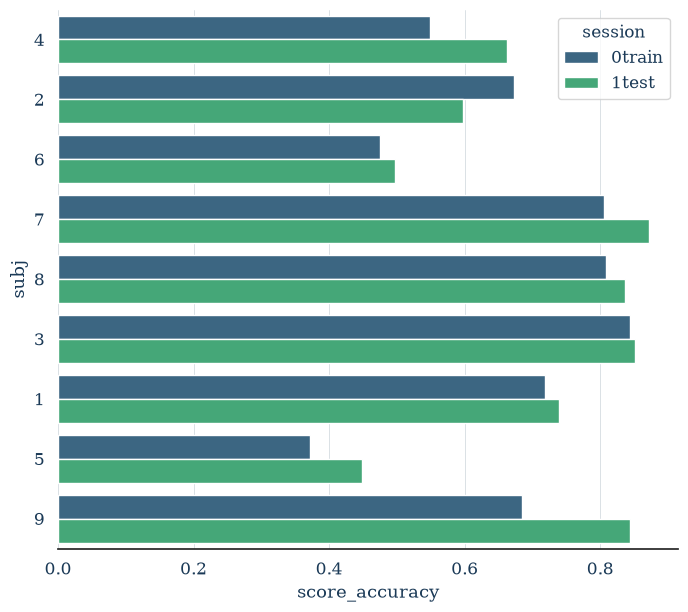

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score_accuracy", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()

## save data

In [ ]:
import numpy as np
for i in range(1, 10):
    X2, labels2, meta2 = paradigm.get_data(dataset=dataset, subjects=[i])
    name="X"+str(i)+".npy"
    labelsName="X"+str(i)+"L.npy"
    metaName="X"+str(i)+"M.npy"

    np.save(name, X2)
    np.save(labelsName, labels2)
    np.save(metaName, meta2)
